In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix

## CNN Architecture for MNIST Classification

This code cell defines a Convolutional Neural Network (CNN) architecture for classifying MNIST digit images. MNIST images have an input shape of **1 × 28 × 28**, meaning:

- **1 channel** (grayscale)  
- **28 pixels height**  
- **28 pixels width**

## Model Structure

The model is composed of three repeated convolutional blocks:

**Conv2d → ReLU → MaxPool2d**

After these three blocks, the tensor is reduced to:

**128 × 1 × 1**

This indicates that the network has learned **128 feature maps**, each compressed to a **1 × 1** spatial representation.

## Layer Explanations

- **Conv2d**  
  Applies a 2D convolution to extract features such as edges, curves, and digit patterns.

- **ReLU**  
  Introduces non-linearity, enabling the network to learn complex relationships.

- **MaxPool2d**  
  Reduces spatial dimensions by selecting the maximum value within a sliding window.

- **Flatten**  
  Converts the multi-dimensional tensor into a one-dimensional vector.

- **Linear**  
  Maps the extracted features to **10 output classes** (digits 0–9).

## Tensor Shape Progression

Input image: 1 × 28 × 28
After block 1: 32 × 13 × 13
After block 2: 64 × 5 × 5
After block 3: 128 × 1 × 1
Final output: 10 class scores

## Architecture Overview

- The CNN progressively reduces spatial dimensions while increasing feature depth.  
- By the final layer, the model captures high-level features in a compact representation.  
- The final linear layer performs classification into 10 digit categories.

In [3]:
class MNISTCnn(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Training with Backpropagation - Enhanced for 3D Visualization

The Python train function below has been **enhanced to collect batch-level loss data** for 3D visualization. Unlike the standard training function that only returns average epoch loss, this version:

1. Tracks the loss for **every batch** during training
2. Returns both the average epoch loss and a list of all batch losses
3. Enables us to visualize the fine-grained training dynamics

For each batch, it moves the data to the compute device, runs a forward pass to generate predictions, computes the loss compared to the true labels, performs backpropagation to calculate gradients, and updates the model weights using the optimizer. The batch-level losses reveal how quickly the model learns within each epoch and whether learning is smooth or erratic.

In [4]:
def train(model, compute_device, train_loader, optimizer, loss_fn):
    model.train()

    total_loss = 0
    batch_losses = []

    for images, labels in train_loader:
        images = images.to(compute_device)
        labels = labels.to(compute_device)

        optimizer.zero_grad()
        predictions = model(images)
        loss = loss_fn(predictions, labels)
        loss.backward()
        optimizer.step()

        batch_loss = loss.item()
        total_loss += batch_loss
        batch_losses.append(batch_loss)

    avg_loss = total_loss / len(train_loader)
    return avg_loss, batch_losses

## Test the CNN Architecture

The Python test function evaluates the model on test data by running it in evaluation mode and disabling gradient calculations. It also collects predictions and true labels to generate detailed metrics like precision, recall, F1-score, and a confusion matrix. Note, the key difference from the previous training function is that this code does not update the model weights — it only measures performance. It uses `model.eval()` and `torch.no_grad()` to turn off learning.

In [5]:
def test(model, compute_device, test_loader, loss_fn):
    model.eval()

    total_loss = 0
    correct = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(compute_device)
            labels = labels.to(compute_device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            total_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    avg_loss = total_loss / len(test_loader)
    accuracy = correct / len(test_loader.dataset)

    print(f"Test loss: {avg_loss:.4f}")
    print(f"Test accuracy: {accuracy:.2%}")

    print("\nPrecision, Recall, and F1-score:")
    print(classification_report(
        all_labels,
        all_predictions,
        digits=4
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_predictions))

## 3D Loss Visualization

This function creates a **3D surface plot** of the training loss landscape, providing insights that 2D plots cannot reveal:

### What the 3D Plot Shows:

- **X-axis (Epoch)**: Training progression over time
- **Y-axis (Batch)**: Position within each epoch
- **Z-axis (Loss)**: Loss value at each point

### Key Insights from 3D Visualization:

1. **Intra-Epoch Learning**: See how loss decreases within each epoch as the model processes batches
2. **Inter-Epoch Progress**: Compare early vs. late epochs to observe overall improvement
3. **Training Stability**: Smooth surfaces indicate stable training; rough surfaces suggest instability
4. **Convergence Patterns**: Identify if the model is still improving or has plateaued

The function creates both a **3D surface plot** (showing the continuous loss landscape) and a **3D scatter plot** (showing individual batch loss points). The color gradient helps visualize high (red) to low (blue) loss regions.

In [6]:
def plot_losses_3d(all_batch_losses):
    """
    Create 3D visualization of training loss across epochs and batches.
    
    Args:
        all_batch_losses: List of lists, where each inner list contains
                         batch losses for one epoch
    """
    # Prepare data for 3D plotting
    epochs = []
    batches = []
    losses = []
    
    for epoch_idx, batch_losses in enumerate(all_batch_losses):
        for batch_idx, loss in enumerate(batch_losses):
            epochs.append(epoch_idx + 1)
            batches.append(batch_idx + 1)
            losses.append(loss)
    
    epochs = np.array(epochs)
    batches = np.array(batches)
    losses = np.array(losses)
    
    # Create figure with two subplots
    fig = plt.figure(figsize=(16, 6))
    
    # First subplot: 3D Surface Plot
    ax1 = fig.add_subplot(121, projection='3d')
    
    # Create meshgrid for surface plot
    num_epochs = len(all_batch_losses)
    num_batches = len(all_batch_losses[0])
    
    X = np.arange(1, num_epochs + 1)
    Y = np.arange(1, num_batches + 1)
    X, Y = np.meshgrid(X, Y)
    
    # Reshape losses into 2D grid
    Z = np.zeros((num_batches, num_epochs))
    for epoch_idx, batch_losses in enumerate(all_batch_losses):
        for batch_idx, loss in enumerate(batch_losses):
            Z[batch_idx, epoch_idx] = loss
    
    # Plot surface
    surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, 
                            edgecolor='none', antialiased=True)
    
    ax1.set_xlabel('Epoch', fontsize=10, labelpad=8)
    ax1.set_ylabel('Batch', fontsize=10, labelpad=8)
    ax1.set_zlabel('Loss', fontsize=10, labelpad=8)
    ax1.set_title('3D Training Loss Surface\n(Epoch × Batch × Loss)', fontsize=12, pad=15)
    ax1.view_init(elev=25, azim=45)
    
    # Add colorbar
    fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5, label='Loss')
    
    # Second subplot: 3D Scatter Plot
    ax2 = fig.add_subplot(122, projection='3d')
    
    scatter = ax2.scatter(epochs, batches, losses, c=losses, cmap='plasma', 
                          s=10, alpha=0.6, edgecolors='none')
    
    ax2.set_xlabel('Epoch', fontsize=10, labelpad=8)
    ax2.set_ylabel('Batch', fontsize=10, labelpad=8)
    ax2.set_zlabel('Loss', fontsize=10, labelpad=8)
    ax2.set_title('3D Training Loss Scatter\n(Individual Batch Points)', fontsize=12, pad=15)
    ax2.view_init(elev=25, azim=45)
    
    # Add colorbar
    fig.colorbar(scatter, ax=ax2, shrink=0.5, aspect=5, label='Loss')
    
    plt.tight_layout()
    plt.savefig("mnist_cnn_loss_3d.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # Additional 2D comparison plot for reference
    fig2, ax = plt.subplots(figsize=(12, 5))
    
    for epoch_idx, batch_losses in enumerate(all_batch_losses):
        batch_indices = np.arange(1, len(batch_losses) + 1)
        ax.plot(batch_indices, batch_losses, alpha=0.6, linewidth=1, 
                label=f'Epoch {epoch_idx + 1}')
    
    ax.set_xlabel('Batch Number', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title('Training Loss per Batch (All Epochs Overlaid)', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    
    plt.tight_layout()
    plt.savefig("mnist_cnn_loss_batches.png", dpi=150, bbox_inches='tight')
    plt.show()

## Device Information

This code prints basic hardware information for the selected compute device, showing GPU/CUDA details when PyTorch is using CUDA. If CUDA is not available, it reports CPU processor, core count, and total system RAM.

In [7]:
import platform
import psutil

def print_device_info(compute_device):
    print(f"Using device: {compute_device}")

    if compute_device.type == "cuda":
        print("\n--- GPU Compute Device Info ---")
        print(f"GPU Name: {torch.cuda.get_device_name(0)}")
        print(f"CUDA Version: {torch.version.cuda}")
        print(f"Number of GPUs: {torch.cuda.device_count()}")

        total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
        reserved_mem = torch.cuda.memory_reserved(0) / 1e9
        allocated_mem = torch.cuda.memory_allocated(0) / 1e9

        print(f"Total GPU Memory: {total_mem:.2f} GB")
        print(f"Reserved GPU Memory: {reserved_mem:.2f} GB")
        print(f"Allocated GPU Memory: {allocated_mem:.2f} GB")

    else:
        print("\n--- CPU Compute Device Info ---")
        print(f"Processor: {platform.processor()}")
        print(f"Logical Cores: {psutil.cpu_count(logical=True)}")
        print(f"Physical Cores: {psutil.cpu_count(logical=False)}")

        mem = psutil.virtual_memory()

        print(f"Total RAM: {mem.total / 1e9:.2f} GB")

## Main Demonstration with 3D Visualization

This code cell sets up and runs the full workflow for training a CNN on the MNIST dataset **with enhanced 3D visualization**.

First, it prepares the environment by selecting the compute device (GPU if available, otherwise CPU), loading the MNIST training and test data, and applying basic preprocessing (converting images to tensors and normalizing them). It then creates data loaders to feed the images to the model in batches, builds the CNN model, and defines the optimizer and loss function.

Next, the code trains the model over multiple epochs. **Crucially, it now collects batch-level losses** from each epoch, storing them in a nested list structure where each inner list represents one epoch's batch losses. This granular data enables the 3D visualization.

Finally, it periodically evaluates the model on the test dataset to measure performance and, at the end, creates comprehensive visualizations:
- **3D surface and scatter plots** showing the complete loss landscape
- **2D overlay plots** showing batch-level loss patterns across epochs

Using device: cpu

--- CPU Compute Device Info ---
Processor: Intel64 Family 6 Model 143 Stepping 4, GenuineIntel
Logical Cores: 8
Physical Cores: 8
Total RAM: 17.18 GB

Epoch 1/15
Training loss: 0.1769

Epoch 2/15
Training loss: 0.0612

Epoch 3/15
Training loss: 0.0426

Epoch 4/15
Training loss: 0.0347

Epoch 5/15
Training loss: 0.0268
Test loss: 0.0479
Test accuracy: 98.55%

Precision, Recall, and F1-score:
              precision    recall  f1-score   support

           0     0.9828    0.9888    0.9858       980
           1     0.9904    0.9991    0.9947      1135
           2     0.9931    0.9709    0.9819      1032
           3     0.9891    0.9891    0.9891      1010
           4     0.9722    0.9980    0.9849       982
           5     0.9853    0.9798    0.9826       892
           6     0.9947    0.9812    0.9879       958
           7     0.9658    0.9893    0.9774      1028
           8     0.9857    0.9908    0.9882       974
           9     0.9969    0.9663    0.9814   

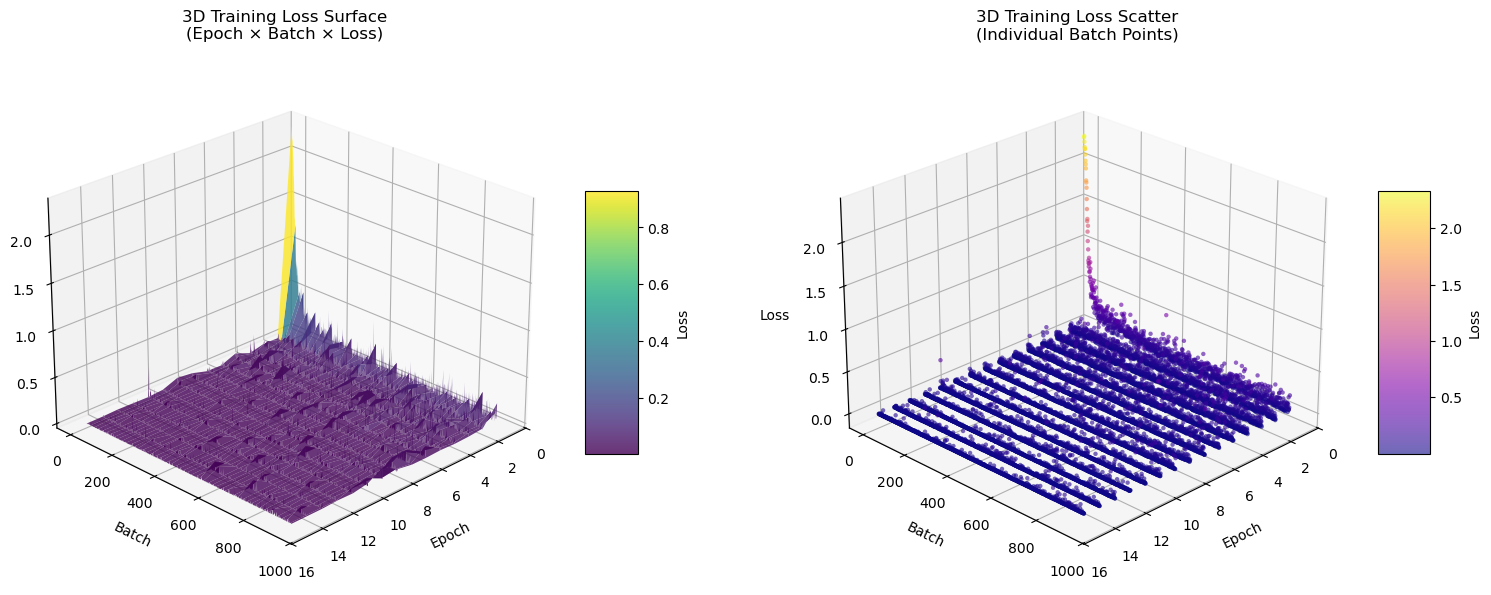

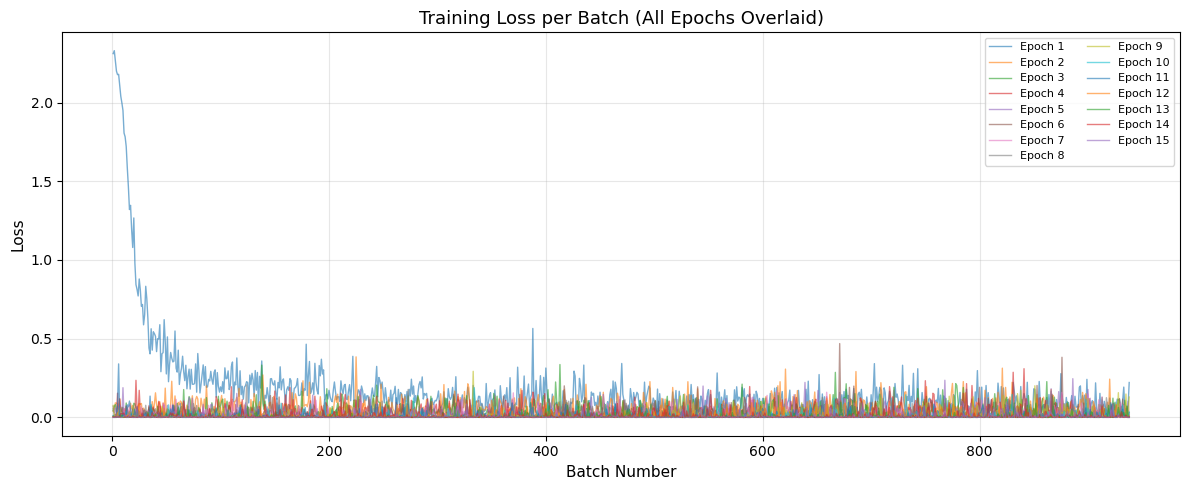


Training complete! 3D visualizations saved.


In [8]:
def main():
    compute_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print_device_info(compute_device)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = datasets.MNIST(
        root="data",
        train=True,
        download=True,
        transform=transform
    )

    test_dataset = datasets.MNIST(
        root="data",
        train=False,
        download=True,
        transform=transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=1000,
        shuffle=False
    )

    model = MNISTCnn().to(compute_device)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    train_losses = []
    all_batch_losses = []  # Store batch losses for 3D visualization

    EPOCHS = 15

    for epoch in range(1, EPOCHS + 1):
        print(f"\nEpoch {epoch}/{EPOCHS}")
        
        # Enhanced: collect both avg loss and batch losses
        train_loss, batch_losses = train(model, compute_device, train_loader, optimizer, loss_fn)
        train_losses.append(train_loss)
        all_batch_losses.append(batch_losses)
        
        print(f"Training loss: {train_loss:.4f}")
        
        # Evaluate on test set periodically and at the end
        if epoch % 5 == 0 or epoch == EPOCHS:
            test(model, compute_device, test_loader, loss_fn)

    # Create 3D visualization
    print("\nGenerating 3D visualizations...")
    plot_losses_3d(all_batch_losses)
    
    print("\nTraining complete! 3D visualizations saved.")

if __name__ == "__main__":
    main()